In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [6]:
class ChatState(BaseModel):
    messages:Annotated[list, add_messages]

In [7]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
def chatBotNode(state:ChatState) ->  ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [7]:
memory = InMemorySaver()

In [9]:
graph = StateGraph(ChatState)
graph.add_node("chatBot", chatBotNode)

graph.add_edge(START, "chatBot")
graph.add_edge("chatBot", END)

graph = graph.compile(checkpointer=memory)

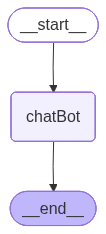

In [10]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [16]:
config = {"configurable":{"thread_id":"my-bot-1"}}
res = graph.invoke(
    {"messages":[{"role":"user", "content":"What is my name ?"}]},
    config
    )

In [17]:
res["messages"][-1].content

'Your name is Prateek Mishra.'